# 2 · Linear algebra: spaces, operators, conjugate gradients

In SpaceCore a **space** is more than a shape: it knows its geometry (the inner product),
how to validate elements, and how to interpret adjoints. An **operator** is a *typed map*
$A : X \to Y$ between spaces — not just an array.

This notebook builds the two core objects and uses them to solve a linear system with the
conjugate gradient (CG) method, entirely through SpaceCore.

**You will learn to**

1. create coordinate spaces with Euclidean and weighted geometry;
2. read geometry through `inner`, `norm`, and the Riesz map;
3. build operators (`DenseLinOp`, `DiagonalLinOp`) and apply them and their adjoints;
4. solve a symmetric positive-definite system with `sc.cg` and watch it converge.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import spacecore as sc

# A clean, consistent palette + style for every figure in the tutorials.
BLUE, INDIGO, CYAN = "#2563eb", "#4f46e5", "#0891b2"
PINK, AMBER, GREEN = "#db2777", "#d97706", "#059669"
SLATE, GRID = "#334155", "#e5e9f0"

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2), "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": SLATE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": SLATE,
    "axes.labelcolor": SLATE, "axes.labelsize": 11,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.4, "lines.markersize": 6, "image.cmap": "magma",
})
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=[BLUE, PINK, GREEN, AMBER, INDIGO, CYAN])

print("spacecore", sc.__version__, "| numpy", np.__version__)

spacecore 0.4.0 | numpy 2.4.2


In [2]:
ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)

## 1 · A space carries geometry

`DenseVectorSpace((n,), ctx)` describes one vector in $\mathbb{R}^n$. With the default
geometry the inner product is the ordinary dot product.

In [3]:
X = sc.DenseVectorSpace((3,), ctx)
x = ctx.asarray([3.0, 4.0, 0.0])
y = ctx.asarray([0.0, 1.0, 2.0])

print("shape       :", X.shape)
print("<x, y>      :", X.inner(x, y))     # dot product
print("||x||       :", X.norm(x))         # sqrt(<x,x>)
print("euclidean?  :", X.is_euclidean)

shape       : (3,)
<x, y>      : 4.0
||x||       : 5.0
euclidean?  : True


### Weighted geometry changes the ruler

A *weighted* inner product keeps the same coordinates but measures them differently:
$\langle x, y\rangle_W = \sum_i w_i\, x_i y_i$. The geometry shows up visually as the shape of
the **unit ball** $\{x : \|x\|=1\}$ — a circle in Euclidean geometry, an ellipse under
weights.

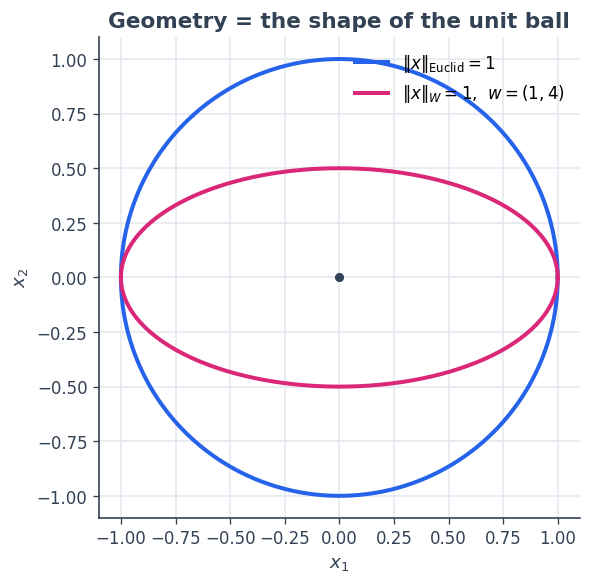

Euclidean ||(0,1)|| : 1.0
Weighted  ||(0,1)|| : 2.0  (= sqrt(4))


In [4]:
w  = ctx.asarray([1.0, 4.0])
Xe = sc.DenseVectorSpace((2,), ctx)                                   # Euclidean
Xw = sc.DenseVectorSpace((2,), ctx, geometry=sc.WeightedInnerProduct(w))

theta = np.linspace(0, 2*np.pi, 256)
circle = np.stack([np.cos(theta), np.sin(theta)])                    # Euclidean unit ball
ellipse = circle / np.sqrt(np.asarray(w))[:, None]                   # weighted unit ball

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot(*circle,  color=BLUE, label=r"$\|x\|_{\mathrm{Euclid}} = 1$")
ax.plot(*ellipse, color=PINK, label=r"$\|x\|_{W} = 1$,  $w=(1,4)$")
ax.scatter([0], [0], color=SLATE, s=20, zorder=5)
ax.set_aspect("equal"); ax.set_title("Geometry = the shape of the unit ball")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend(loc="upper right")
plt.show()

print("Euclidean ||(0,1)|| :", float(Xe.norm(ctx.asarray([0.0, 1.0]))))
print("Weighted  ||(0,1)|| :", float(Xw.norm(ctx.asarray([0.0, 1.0]))), " (= sqrt(4))")

The **Riesz map** turns a coordinate vector into the dual vector that represents it under
the geometry. For Euclidean geometry it is the identity; for weights $w$ it multiplies by
$w$. It is what makes gradients and adjoints *metric-aware* (you will use it in tutorials 3
and 6).

In [5]:
v = ctx.asarray([1.0, 1.0])
print("Euclidean riesz:", Xe.riesz(v))   # identity
print("Weighted  riesz:", Xw.riesz(v))   # multiply by w = (1, 4)

Euclidean riesz: [1. 1.]
Weighted  riesz: [1. 4.]


## 2 · Operators are typed maps $A : X \to Y$

`DenseLinOp(A, dom, cod, ctx)` wraps a matrix as a map between *spaces*. `apply` is the
forward map; `rapply` is the **adjoint with respect to the spaces' inner products**
(for Euclidean spaces this is the ordinary transpose; see
[design/geometry](../design/geometry.rst) for the metric case).

In [6]:
M  = ctx.asarray([[2.0, 1.0],
                  [1.0, 3.0]])
X2 = sc.DenseVectorSpace((2,), ctx)
A  = sc.DenseLinOp(M, X2, X2, ctx)

u = ctx.asarray([1.0, 0.0])
print("A u        :", A.apply(u))
print("A* (1,1)   :", A.rapply(ctx.asarray([1.0, 1.0])))   # adjoint
print("hermitian? :", A.is_hermitian())

# A diagonal operator only stores its diagonal:
D = sc.DiagonalLinOp(ctx.asarray([2.0, 0.5]), X2, ctx)
print("D (1,1)    :", D.apply(ctx.asarray([1.0, 1.0])))

A u        : [2. 1.]
A* (1,1)   : [3. 4.]
hermitian? : True
D (1,1)    : [2.  0.5]


### Seeing an operator as a deformation

A linear map sends the unit circle to an ellipse whose axes are the eigenvectors of $A$,
stretched by its eigenvalues. Visualising that makes "operator" concrete.

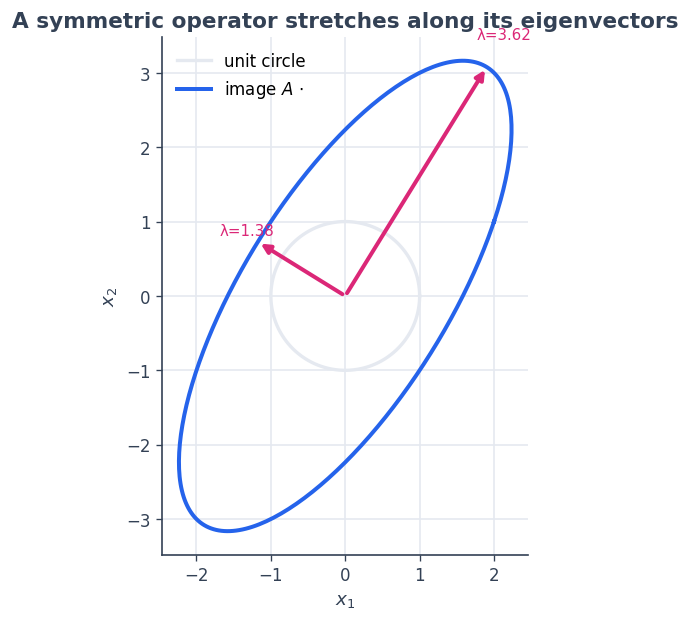

In [7]:
pts = circle                                    # reuse the unit circle from before
img = np.asarray(A.to_dense()) @ pts
evals, evecs = np.linalg.eigh(np.asarray(M))

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot(*pts, color=GRID, lw=2, label="unit circle")
ax.plot(*img, color=BLUE, label=r"image $A\,\cdot$")
for lam, vec in zip(evals, evecs.T):
    ax.annotate("", xy=lam*vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=PINK, lw=2.4))
    ax.text(*(lam*vec*1.12), f"λ={lam:.2f}", color=PINK, fontsize=9, ha="center")
ax.set_aspect("equal"); ax.set_title("A symmetric operator stretches along its eigenvectors")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend(loc="upper left")
plt.show()

## 3 · Solving $A x = b$ with conjugate gradients

`sc.cg` expects a square, symmetric, positive-definite operator and solves $Ax = b$ using
only `A.apply` and the domain inner product — it never forms $A^{-1}$. We build a classic
SPD example: a 1-D discrete Laplacian (tridiagonal $2,-1$).

In [8]:
n = 40
lap = (2.0 * np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1))
Xn  = sc.DenseVectorSpace((n,), ctx)
L   = sc.DenseLinOp(ctx.asarray(lap), Xn, Xn, ctx)

b   = ctx.asarray(np.ones(n))
res = sc.cg(L, b, tol=1e-10, maxiter=n)

print("converged   :", bool(res.converged))
print("iterations  :", int(res.num_iters))
print("residual    :", float(res.residual_norm))
print("check Ax≈b   :", np.allclose(np.asarray(L.apply(res.x)), np.asarray(b)))

converged   : True
iterations  : 40
residual    : 7.869487166620889e-29
check Ax≈b   : True


To *watch* CG converge we ask it for the residual after $k$ steps, for $k = 1, 2, \dots$
(re-running from scratch with `tol=0` so it always takes exactly $k$ iterations). The
residual drops sharply once CG has explored enough of the Krylov subspace.

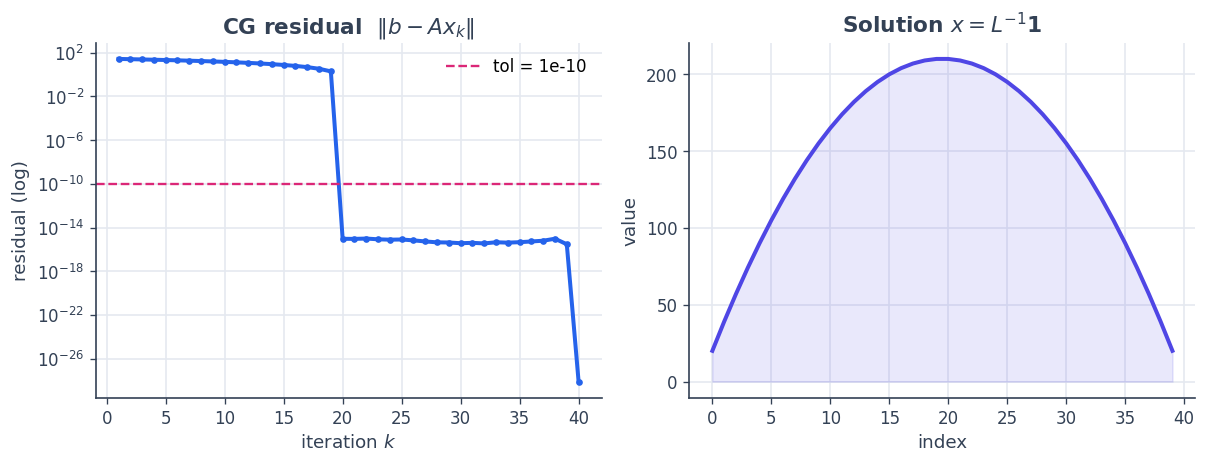

In [9]:
ks = np.arange(1, n + 1)
hist = [float(sc.cg(L, b, tol=0.0, atol=0.0, maxiter=int(k), check_every=1).residual_norm)
        for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0))
axes[0].semilogy(ks, hist, color=BLUE, marker="o", ms=3)
axes[0].axhline(1e-10, color=PINK, ls="--", lw=1.4, label="tol = 1e-10")
axes[0].set_title("CG residual  $\\|b - A x_k\\|$"); axes[0].set_xlabel("iteration $k$")
axes[0].set_ylabel("residual (log)"); axes[0].legend()

axes[1].plot(np.asarray(res.x), color=INDIGO)
axes[1].fill_between(np.arange(n), np.asarray(res.x), color=INDIGO, alpha=0.12)
axes[1].set_title("Solution $x = L^{-1}\\mathbf{1}$"); axes[1].set_xlabel("index")
axes[1].set_ylabel("value")
plt.tight_layout(); plt.show()

The solution is the smooth "tent" you expect from inverting a Laplacian against a constant
load — recovered with a handful of operator applications and no explicit matrix inverse.

## Recap

* A **space** owns geometry: `inner`, `norm`, `riesz`, and `is_euclidean`. Weighting the
  inner product reshapes the unit ball.
* An **operator** $A : X \to Y$ has `apply` (forward) and `rapply` (metric adjoint), and can
  be materialised with `to_dense()`.
* **`sc.cg`** solves SPD systems matrix-free, using only `apply` and the space's inner
  product.

**Next:** [3 · Functionals](03_functionals.ipynb) — scalar objectives, metric-aware
gradients, and gradient descent.